<a href="https://colab.research.google.com/github/gpreti/EE-629/blob/main/EX3/EX3_GraphMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import numpy as np
import scipy.io
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================
# Clone entire Github repository
# ============================

!git clone https://github.com/gpreti/EE-629.git

print("Repository cloned.") #everything exist locally now, path: "EE-629/EX2/"

Cloning into 'EE-629'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 268 (delta 16), reused 1 (delta 1), pack-reused 202 (from 1)
Receiving objects: 100% (268/268), 77.77 MiB | 31.10 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Repository cloned.


In [8]:
##### to pull when adding new files into github
%cd /content/EE-629
!git pull

/content/EE-629
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 22 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (22/22), 1.83 MiB | 11.00 MiB/s, done.
From https://github.com/gpreti/EE-629
   eb7a491..e370230  main       -> origin/main
Updating eb7a491..e370230
Fast-forward
 EX3/DATA/FC.mat           | Bin 0 -> 984915 bytes
 EX3/DATA/SC.mat           | Bin 0 -> 924011 bytes
 EX3/DATA/readme.txt       |   3 +++
 EX3/EX_GraphMetrics.ipynb |   1 -
 4 files changed, 3 insertions(+), 1 deletion(-)
 create mode 100644 EX3/DATA/FC.mat
 create mode 100644 EX3/DATA/SC.mat
 create mode 100644 EX3/DATA/readme.txt
 delete mode 100644 EX3/EX_GraphMetrics.ipynb


In [13]:


path_exercise='EE-629/EX3/'

# Load SC Data
SC_file = os.path.join(path_exercise, 'DATA', 'SC.mat')
SC = scipy.io.loadmat(SC_file)
print("Variables in .mat file:", SC.keys())

# Extract the main SC variable
SCvar = SC['SC']  # shape: (regions, regions)
print("SC shape (regions x regions):", SCvar.shape)

n_regions = SCvar.shape[0]

# Visualize matrix
plt.figure(figsize=(6,5))

plt.imshow(SCvar, interpolation='nearest')
plt.colorbar(label="Structural connectivity strength")

plt.title("Structural Connectome")
plt.xlabel("Node")
plt.ylabel("Node")

plt.tight_layout()
plt.show()

Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'SC'])
SC shape (regions x regions): (360, 360)


Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'FC'])
FC shape (regions x regions): (360, 360)


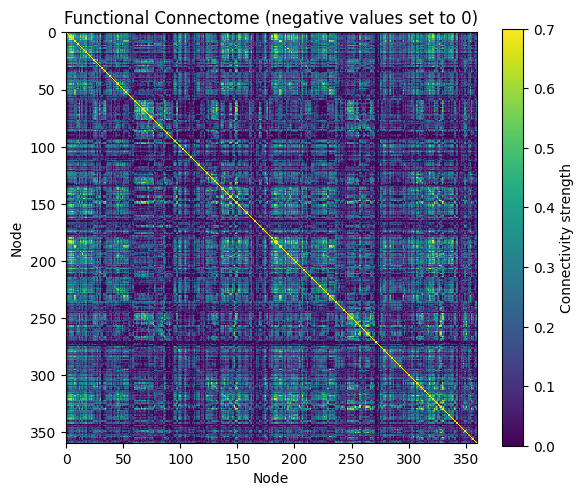

In [18]:
# Load FC Data
FC_file = os.path.join(path_exercise, 'DATA', 'FC.mat')
FC = scipy.io.loadmat(FC_file)
print("Variables in .mat file:", FC.keys())

# Extract the main SC variable
FCvar = FC['FC']  # shape: (regions, regions)
print("FC shape (regions x regions):", FCvar.shape)

n_regions = FCvar.shape[0]

#set negative values to 0 and plot
FCvar_pos = FCvar.copy()
FCvar_pos[FCvar_pos < 0] = 0


# Visualize matrix

plt.figure(figsize=(6,5))

plt.imshow(FCvar_pos, interpolation='nearest',vmin=0, vmax=0.7)
plt.colorbar(label="Functional connectivity strength")

plt.title("Functional Connectome (negative values set to 0)")
plt.xlabel("Node")
plt.ylabel("Node")

plt.tight_layout()
plt.show()

In [15]:
#definition of useful functions
# --------------------------------------------------
# Convert weights to distances for path metrics
# --------------------------------------------------

def weight_to_distance(W):
    W = W.copy()
    W[W == 0] = np.nan
    D = 1 / W
    D[np.isnan(D)] = 0
    return D


# --------------------------------------------------
# Compute metrics
# --------------------------------------------------

def compute_metrics(W):

    G = nx.from_numpy_array(W)

    strength = dict(G.degree(weight='weight'))
    eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')
    clustering = nx.clustering(G, weight='weight')

    D = weight_to_distance(W)
    G_dist = nx.from_numpy_array(D)

    closeness = nx.closeness_centrality(G_dist, distance='weight')
    betweenness = nx.betweenness_centrality(G_dist, weight='weight')

    avg_clustering = nx.average_clustering(G, weight='weight')

    if nx.is_connected(G):
        char_path = nx.average_shortest_path_length(G_dist, weight='weight')
    else:
        char_path = np.nan

    metrics = {
        "strength": strength,
        "eigenvector": eigenvector,
        "closeness": closeness,
        "betweenness": betweenness,
        "clustering": clustering,
        "avg_clustering": avg_clustering,
        "char_path": char_path
    }

    return metrics

In [16]:

metrics_SC = compute_metrics(SCvar)
metrics_FC = compute_metrics(FCvar)


# Prepare node metric arrays

node_metrics = ["strength", "eigenvector", "closeness", "betweenness", "clustering"]

SC_values = {m: np.array(list(metrics_SC[m].values())) for m in node_metrics}
FC_values = {m: np.array(list(metrics_FC[m].values())) for m in node_metrics}

nodes = np.arange(len(SC))


ValueError: ('Contradictory paths found:', 'negative weights?')

In [ ]:
# Plot node metric profiles

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, m in enumerate(node_metrics):

    axes[i].plot(nodes, SC_values[m], marker='o', label='SC')
    axes[i].plot(nodes, FC_values[m], marker='s', label='FC')

    axes[i].set_title(m)
    axes[i].set_xlabel("Node")
    axes[i].set_ylabel("Metric value")
    axes[i].legend()

axes[-1].axis("off")

plt.tight_layout()
plt.show()

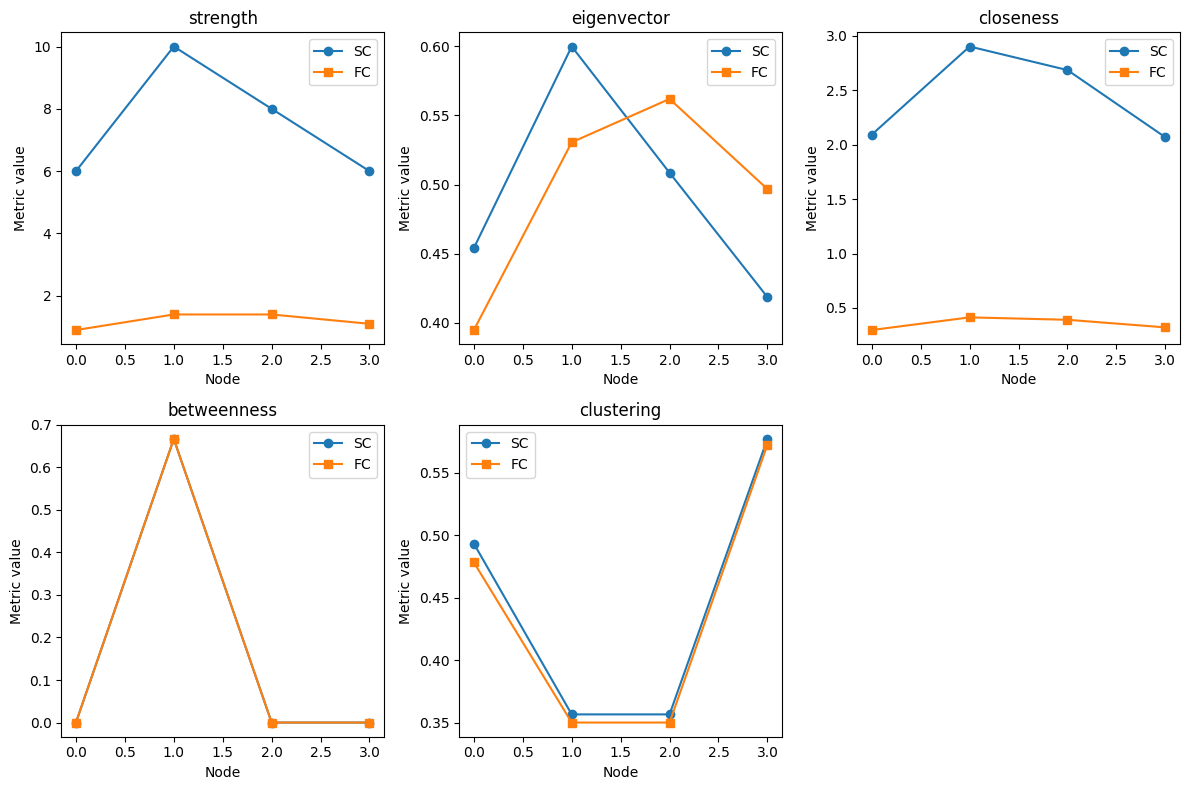

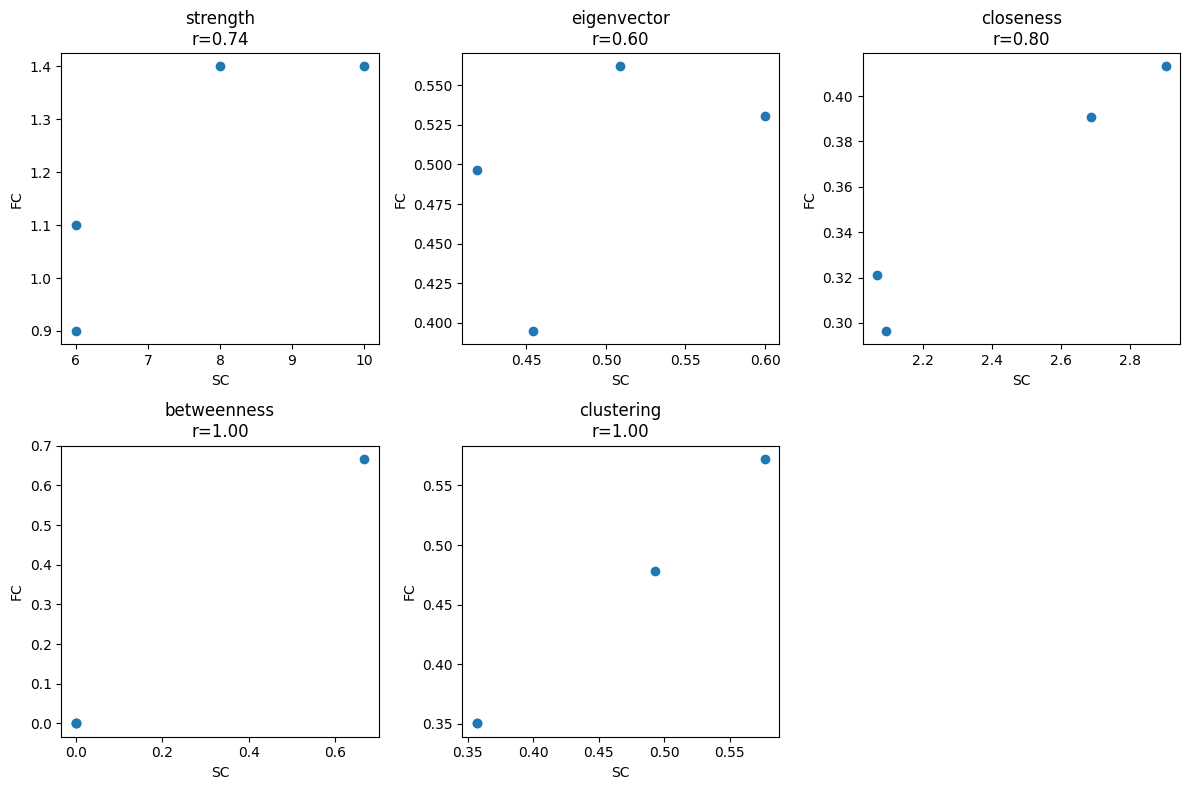

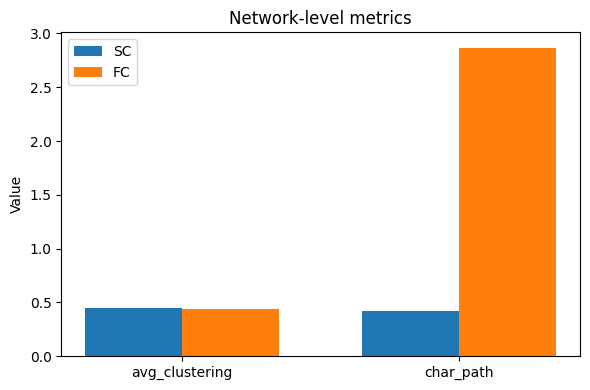

In [ ]:


# Scatter plots (structure-function coupling)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, m in enumerate(node_metrics):

    x = SC_values[m]
    y = FC_values[m]

    r, p = spearmanr(x, y)

    axes[i].scatter(x, y)

    axes[i].set_xlabel("SC")
    axes[i].set_ylabel("FC")
    axes[i].set_title(f"{m}\nr={r:.2f}")

axes[-1].axis("off")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Network-level comparison
# --------------------------------------------------

network_metrics = ["avg_clustering", "char_path"]

SC_net = [metrics_SC[m] for m in network_metrics]
FC_net = [metrics_FC[m] for m in network_metrics]

x = np.arange(len(network_metrics))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, SC_net, width, label="SC")
plt.bar(x + width/2, FC_net, width, label="FC")

plt.xticks(x, network_metrics)
plt.ylabel("Value")
plt.title("Network-level metrics")

plt.legend()

plt.tight_layout()
plt.show()